# Smart Insect Identifier & AI Insights
---
## Final Project - Machine Learning Lab
## Model Architecture: EfficientNet-B3

## 1. Install dan Persiapan Library

In [1]:
!pip install -q timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 74.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

## 2. Import Library dan Inisialisasi Environment

In [2]:
import os
import json
import glob
import time
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from collections import Counter, deque
from tqdm.notebook import tqdm
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
import timm

warnings.filterwarnings('ignore')

# ─── Reproducibility ───
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ─── Device ───
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    gpu_count = torch.cuda.device_count()
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"   GPU count: {gpu_count}")

Device : cuda
   GPU    : Tesla T4
   VRAM   : 15.6 GB
   GPU count: 2


## 3. Eksplorasi Struktur Dataset

In [3]:
BASE_DIR = Path('/kaggle/input')

print('Struktur /kaggle/input (folder only):')

def print_dirs(path, prefix='', max_depth=4, depth=0):
    if depth >= max_depth:
        return
    try:
        dirs = sorted([d for d in path.iterdir() if d.is_dir()])
    except PermissionError:
        return
    for d in dirs:
        print(f'   {prefix}📁 {d.name}')
        print_dirs(d, prefix + '   ', max_depth, depth + 1)

print_dirs(BASE_DIR)

def find_split_dir(base, split_name, max_depth=5):
    queue = deque([(base, 0)])
    while queue:
        current, depth = queue.popleft()
        if depth >= max_depth:
            continue
        try:
            for child in sorted(current.iterdir()):
                if not child.is_dir():
                    continue
                if child.name == split_name:
                    return child
                queue.append((child, depth + 1))
        except PermissionError:
            continue
    return None

TRAIN_DIR = find_split_dir(BASE_DIR, 'train')
VAL_DIR   = find_split_dir(BASE_DIR, 'val')
TEST_DIR  = find_split_dir(BASE_DIR, 'test')

if TRAIN_DIR is None:
    raise FileNotFoundError("Folder 'train' tidak ditemukan!")

print(f'\nTRAIN : {TRAIN_DIR}')
print(f'VAL   : {VAL_DIR}')
print(f'TEST  : {TEST_DIR}')

DATASET_DIR = TRAIN_DIR.parent

classes_file = DATASET_DIR / 'classes.txt'
if classes_file.exists():
    with open(classes_file) as f:
        CLASS_NAMES = [line.strip() for line in f if line.strip()]
    print(f'\nClasses dari classes.txt ({len(CLASS_NAMES)} kelas)')
else:
    CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
    print(f'\nClasses dari subfolder train/ ({len(CLASS_NAMES)} kelas)')

NUM_CLASSES = len(CLASS_NAMES)
print(f"\n{'─'*40}")
for i, name in enumerate(CLASS_NAMES):
    print(f'   {i:>3}. {name}')
print(f"{'─'*40}")
print(f'Total: {NUM_CLASSES} kelas')

Struktur /kaggle/input (folder only):
   📁 datasets
      📁 baxtiyorbotiraliyev
         📁 insects
            📁 dataset
      📁 muliaandiki
         📁 checkcheck
         📁 modelmodel

TRAIN : /kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset/train
VAL   : /kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset/val
TEST  : /kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset/test

Classes dari classes.txt (118 kelas)

────────────────────────────────────────
     0. adristyrannus
     1. aleurocanthus spiniferus
     2. alfalfa plant bug
     3. alfalfa seed chalcid
     4. alfalfa weevil
     5. ampelophaga
     6. ant
     7. aphids
     8. apolygus lucorum
     9. armyworm
    10. asiatic rice borer
    11. bactrocera tsuneonis
    12. bee
    13. beet fly
    14. beetle
    15. black cutworm
    16. blister beetle
    17. bollworm
    18. brevipoalpus lewisi McGregor
    19. brown plant hopper
    20. butterfly
    21. catterpillar
    22. cerodonta denticornis
 

## 4. Analisis Distribusi Data dan Jumlah Gambar

In [4]:
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def count_images_fast(directory: Path):
    counts = {}
    for class_dir in sorted(directory.iterdir()):
        if not class_dir.is_dir():
            continue
        n = sum(1 for p in class_dir.iterdir() if p.suffix.lower() in VALID_EXTS)
        counts[class_dir.name] = n
    return counts

print('Menghitung gambar per kelas...')
train_counts = count_images_fast(TRAIN_DIR)
val_counts   = count_images_fast(VAL_DIR)   if VAL_DIR  else {}
test_counts  = count_images_fast(TEST_DIR)  if TEST_DIR else {}

total_train = sum(train_counts.values())
total_val   = sum(val_counts.values())
total_test  = sum(test_counts.values())
total_all   = total_train + total_val + total_test

print(f"\n{'='*50}")
print(f'RINGKASAN DATASET')
print(f"{'='*50}")
print(f'  Train : {total_train:,} gambar  ({len(train_counts)} kelas)')
print(f'  Val   : {total_val:,}   gambar  ({len(val_counts)} kelas)')
print(f'  Test  : {total_test:,}  gambar  ({len(test_counts)} kelas)')
print(f'  Total : {total_all:,}   gambar')

counts_arr = np.array(list(train_counts.values()))
imbalance_ratio = counts_arr.max() / max(counts_arr.min(), 1)
print(f"\nImbalance ratio (train): {imbalance_ratio:.2f}x")
print(f'   Min samples: {counts_arr.min()} | Max samples: {counts_arr.max()}')
if imbalance_ratio > 5:
    print('Dataset tidak seimbang → akan digunakan WeightedRandomSampler')

Menghitung gambar per kelas...

RINGKASAN DATASET
  Train : 90,115 gambar  (118 kelas)
  Val   : 11,215   gambar  (118 kelas)
  Test  : 11,363  gambar  (118 kelas)
  Total : 112,693   gambar

Imbalance ratio (train): 179.93x
   Min samples: 28 | Max samples: 5038
Dataset tidak seimbang → akan digunakan WeightedRandomSampler


## 5. Visualisasi Distribusi Dataset

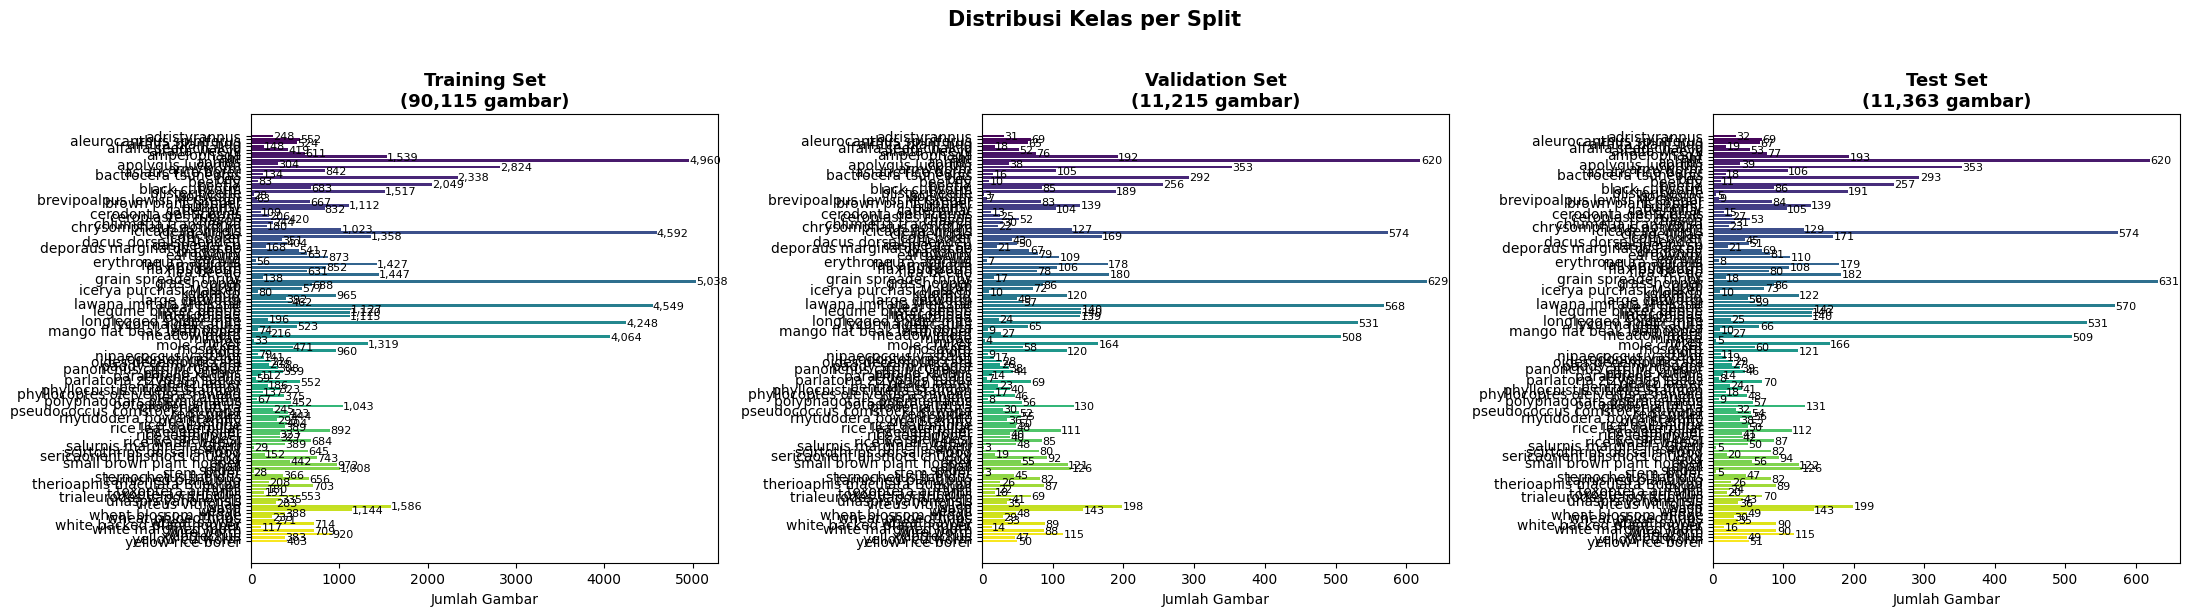

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
palette = sns.color_palette('viridis', NUM_CLASSES)

def plot_class_dist(ax, counts, title, color_palette):
    classes = list(counts.keys())
    values  = list(counts.values())
    bars = ax.barh(classes, values, color=color_palette)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Jumlah Gambar')
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8)
    ax.invert_yaxis()

plot_class_dist(axes[0], train_counts, f'Training Set\n({total_train:,} gambar)', palette)
plot_class_dist(axes[1], val_counts,   f'Validation Set\n({total_val:,} gambar)', palette)
plot_class_dist(axes[2], test_counts,  f'Test Set\n({total_test:,} gambar)', palette)

plt.suptitle('Distribusi Kelas per Split', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Visualisasi Sampel Citra Serangga

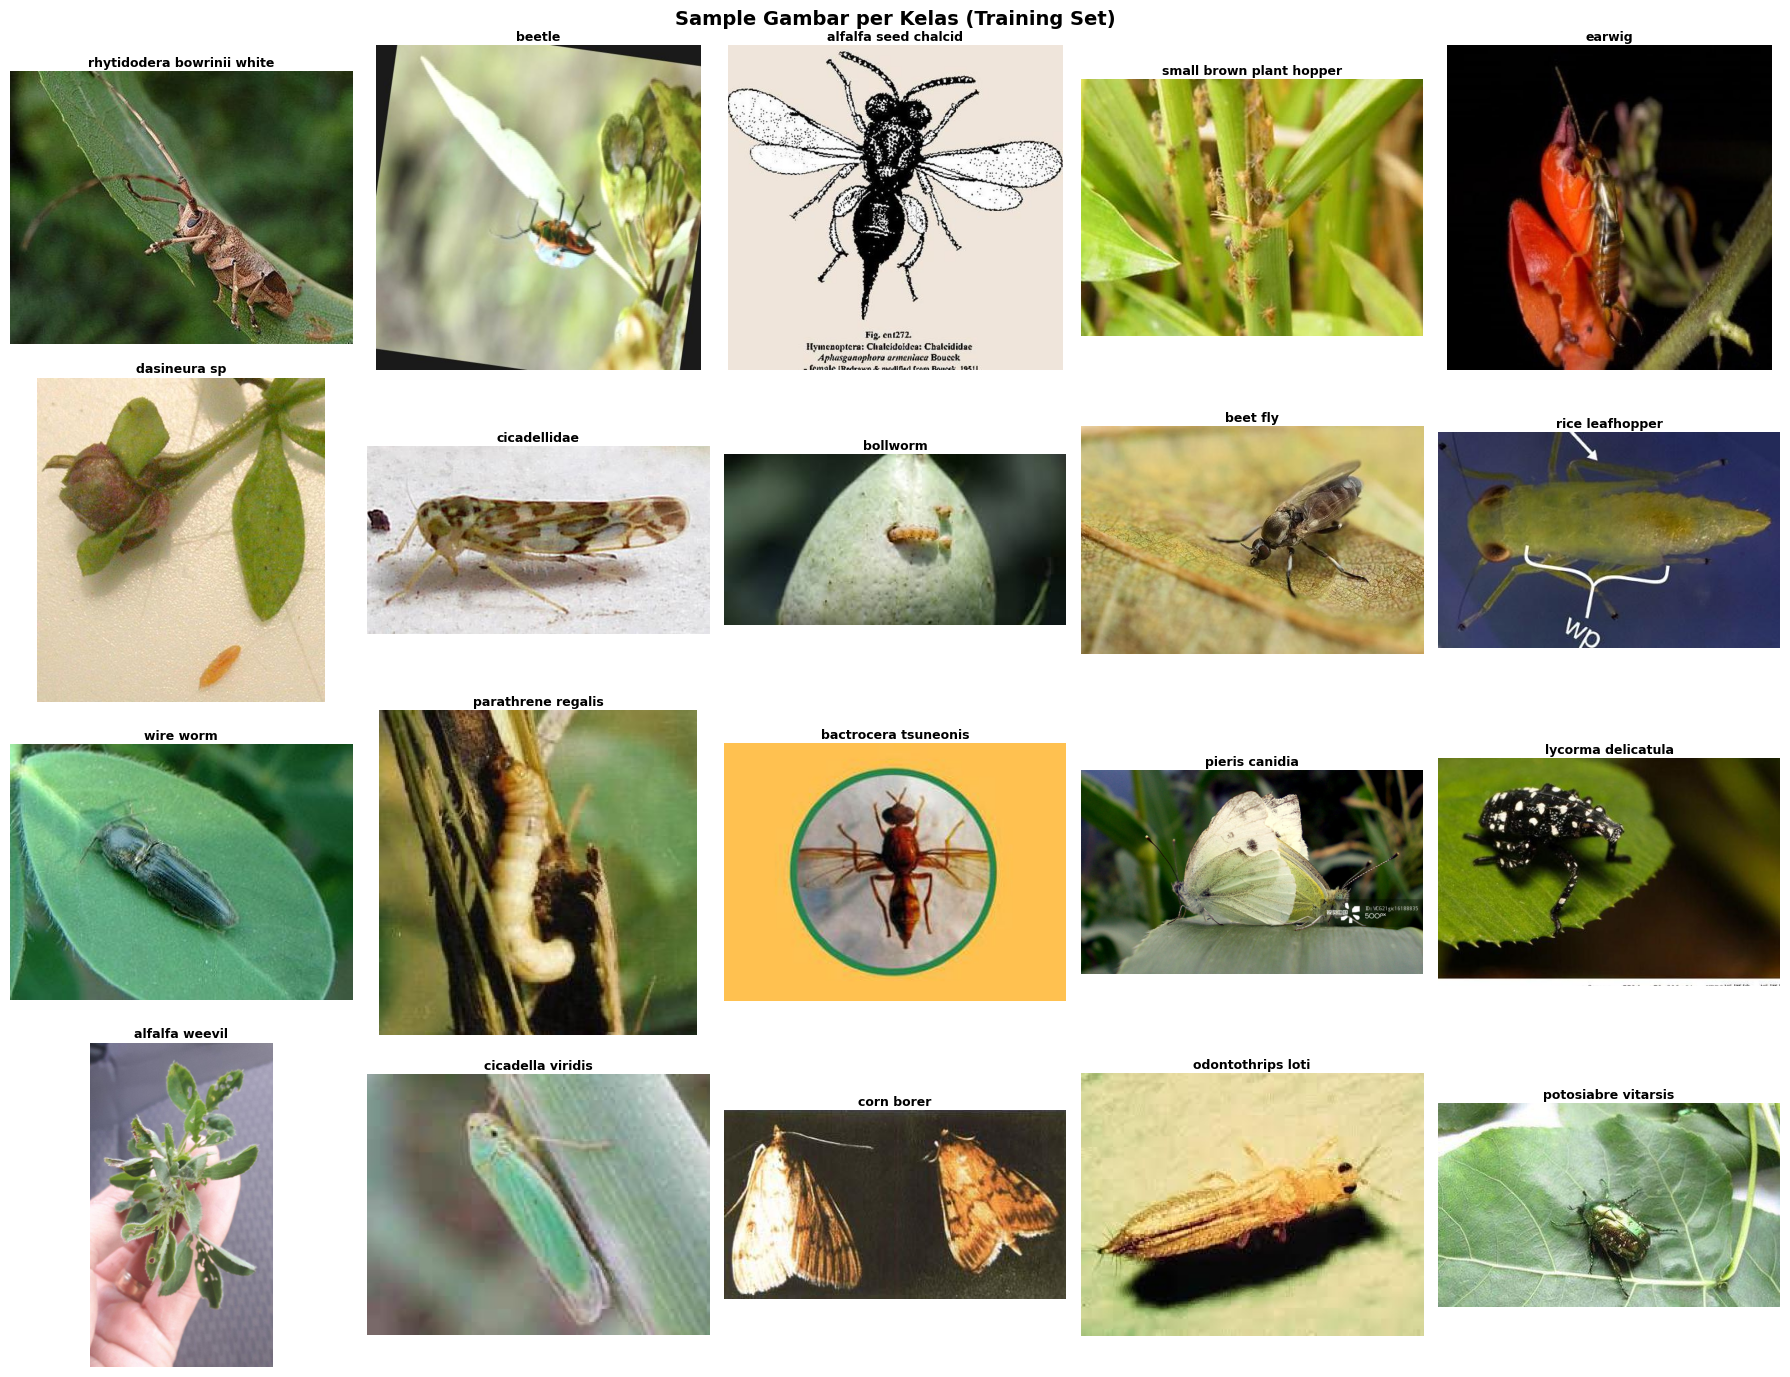

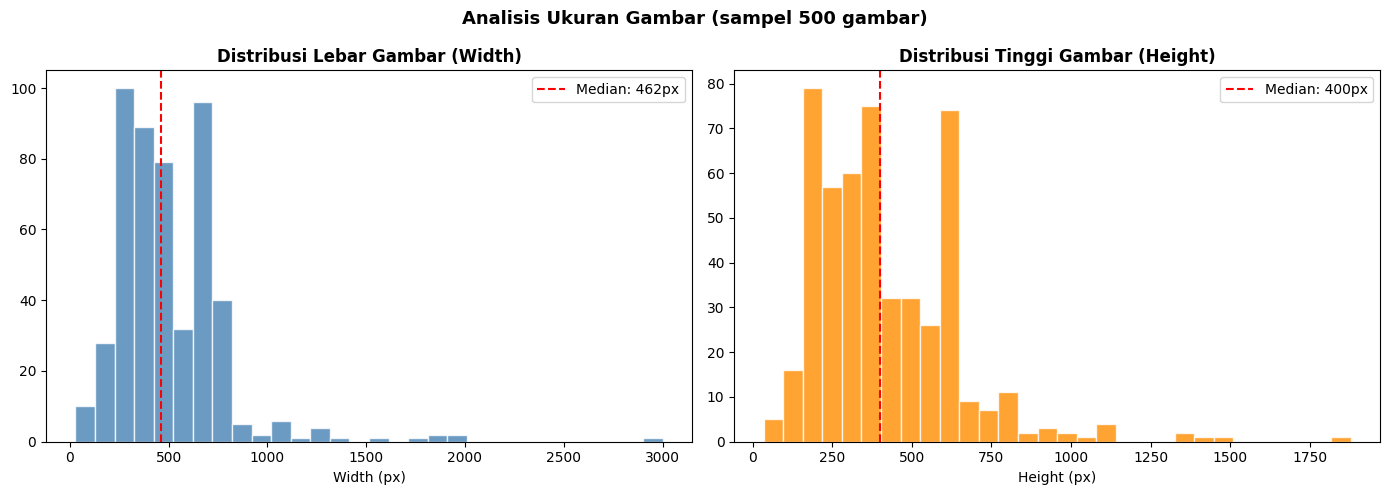

Width  → min:28  max:3000  mean:505  median:462
Height → min:34 max:1879 mean:419 median:400


In [6]:
fig, axes = plt.subplots(4, 5, figsize=(18, 14))
axes = axes.flatten()
sample_classes = random.sample(CLASS_NAMES, min(20, NUM_CLASSES))

for ax, cls in zip(axes, sample_classes):
    cls_dir = TRAIN_DIR / cls
    imgs = [p for p in cls_dir.glob('*') if p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp','.webp'}]
    if not imgs:
        ax.axis('off')
        continue
    try:
        img = Image.open(random.choice(imgs)).convert('RGB')
        ax.imshow(img)
        ax.set_title(cls.replace('_', ' '), fontsize=9, fontweight='bold', pad=3)
        ax.axis('off')
    except Exception:
        ax.axis('off')

for ax in axes[len(sample_classes):]:
    ax.axis('off')

plt.suptitle('Sample Gambar per Kelas (Training Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

# Image size analysis
widths, heights = [], []
sample_limit = 500
all_train_imgs = [
    p for cls_dir in TRAIN_DIR.iterdir() if cls_dir.is_dir()
    for p in cls_dir.iterdir() if p.suffix.lower() in {'.jpg','.jpeg','.png'}
]
sampled = random.sample(all_train_imgs, min(sample_limit, len(all_train_imgs)))
for p in sampled:
    try:
        with Image.open(p) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception:
        pass

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(widths, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(np.median(widths), color='red', linestyle='--', label=f'Median: {np.median(widths):.0f}px')
axes[0].set_title('Distribusi Lebar Gambar (Width)', fontweight='bold')
axes[0].set_xlabel('Width (px)')
axes[0].legend()

axes[1].hist(heights, bins=30, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].axvline(np.median(heights), color='red', linestyle='--', label=f'Median: {np.median(heights):.0f}px')
axes[1].set_title('Distribusi Tinggi Gambar (Height)', fontweight='bold')
axes[1].set_xlabel('Height (px)')
axes[1].legend()

plt.suptitle(f'Analisis Ukuran Gambar (sampel {len(widths)} gambar)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('image_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Width  → min:{min(widths)}  max:{max(widths)}  mean:{np.mean(widths):.0f}  median:{np.median(widths):.0f}")
print(f"Height → min:{min(heights)} max:{max(heights)} mean:{np.mean(heights):.0f} median:{np.median(heights):.0f}")

## 7. Konfigurasi Hyperparameter dan Training Setup

In [7]:
CONFIG = {
    'model_name'     : 'efficientnet_b3',
    'img_size'       : 300,
    'num_classes'    : NUM_CLASSES,
    'batch_size'     : 32,
    'num_workers'    : 4,
    'epochs'         : 100,
    'lr_head'        : 1e-3,
    'lr_backbone'    : 1e-5,
    'weight_decay'   : 1e-4,
    'label_smoothing': 0.1,
    'patience'       : 10,
    'min_delta'      : 1e-4,
    'scheduler'      : 'cosine',
    'warmup_epochs'  : 3,
    'save_path'      : '/kaggle/working/best_model.pth',
    'metadata_path'  : '/kaggle/working/model_metadata.json',
    'checkpoint_dir' : '/kaggle/working/checkpoints',   # ← BARU: folder checkpoint
}

IMG_SIZE   = CONFIG['img_size']
BATCH_SIZE = CONFIG['batch_size']

print("Konfigurasi:")
for k, v in CONFIG.items():
    print(f"   {k:<20} : {v}")

Konfigurasi:
   model_name           : efficientnet_b3
   img_size             : 300
   num_classes          : 118
   batch_size           : 32
   num_workers          : 4
   epochs               : 100
   lr_head              : 0.001
   lr_backbone          : 1e-05
   weight_decay         : 0.0001
   label_smoothing      : 0.1
   patience             : 10
   min_delta            : 0.0001
   scheduler            : cosine
   warmup_epochs        : 3
   save_path            : /kaggle/working/best_model.pth
   metadata_path        : /kaggle/working/model_metadata.json
   checkpoint_dir       : /kaggle/working/checkpoints


## 8. Sistem Checkpoint dan Resume Training

In [8]:
# ─── Checkpoint: Save & Load ─── (BARU dari fixed version)

os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)

def save_checkpoint(epoch, phase, model, optimizer, scheduler, best_val_loss, best_val_acc, history, scaler=None):
    """Simpan checkpoint per-epoch. Pertahankan hanya 2 checkpoint terbaru."""
    state_dict = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
    path = f"{CONFIG['checkpoint_dir']}/ckpt_epoch_{epoch:03d}.pth"
    payload = {
        'epoch'          : epoch,
        'phase'          : phase,
        'model_state'    : state_dict,
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'best_val_loss'  : best_val_loss,
        'best_val_acc'   : best_val_acc,
        'history'        : history,
    }
    if scaler is not None:
        payload['scaler_state'] = scaler.state_dict()
    torch.save(payload, path)

    shutil.copy(path, '/kaggle/working/latest_checkpoint.pth')

    # Hapus checkpoint lama, simpan 2 terbaru
    ckpts = sorted(glob.glob(f"{CONFIG['checkpoint_dir']}/ckpt_epoch_*.pth"))
    for old in ckpts[:-2]:
        os.remove(old)
    print(f"Checkpoint saved → epoch {epoch}")


def load_latest_checkpoint():
    # Cek di working dulu
    ckpts = sorted(glob.glob(f"{CONFIG['checkpoint_dir']}/ckpt_epoch_*.pth"))
    if not ckpts:
        # Cek dari input — semua kemungkinan path
        ckpts = sorted(glob.glob('/kaggle/input/**/latest_checkpoint.pth', recursive=True))
    if not ckpts:
        return None
    ckpt = torch.load(ckpts[-1], map_location=DEVICE)
    print(f"Checkpoint ditemukan! Resume dari epoch {ckpt['epoch']} (phase {ckpt.get('phase', '?')})")
    return ckpt

## 9. Implementasi Custom Dataset Loader

In [9]:
class RobustImageFolder(Dataset):
    """ImageFolder yang otomatis skip gambar rusak saat __getitem__."""
    def __init__(self, root, transform=None):
        self.base         = ImageFolder(root, transform=None)
        self.transform    = transform
        self.classes      = self.base.classes
        self.class_to_idx = self.base.class_to_idx
        self.samples      = self.base.samples
        print(f'   {root.name} -> {len(self.samples):,} file ({len(self.classes)} kelas)')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        for _ in range(5):
            try:
                img = Image.open(path).convert('RGB')
                if self.transform:
                    img = self.transform(img)
                return img, label
            except Exception:
                idx = random.randint(0, len(self.samples) - 1)
                path, label = self.samples[idx]
        return torch.zeros(3, CONFIG['img_size'], CONFIG['img_size']), label

## 10. Data Preprocessing dan Augmentasi

In [10]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Dataset loading HANYA SEKALI
print('Memuat dataset...')
print('[Train]')
train_dataset = RobustImageFolder(TRAIN_DIR, transform=train_transform)
print('[Validation]')
val_dataset   = RobustImageFolder(VAL_DIR, transform=val_test_transform)
print('[Test]')
test_dataset  = RobustImageFolder(TEST_DIR, transform=val_test_transform)

print(f'\nDataset siap: Train={len(train_dataset):,} | Val={len(val_dataset):,} | Test={len(test_dataset):,}')

Memuat dataset...
[Train]
   train -> 90,115 file (118 kelas)
[Validation]
   val -> 11,215 file (118 kelas)
[Test]
   test -> 11,363 file (118 kelas)

Dataset siap: Train=90,115 | Val=11,215 | Test=11,363


## 11. Penanganan Imbalanced Dataset dengan Weighted Sampling

In [11]:
def make_weighted_sampler(dataset):
    labels = [label for _, label in dataset.samples]
    class_counts = Counter(labels)
    class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
    sample_weights = [class_weights[label] for label in labels]
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler

train_sampler = make_weighted_sampler(train_dataset)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=CONFIG['num_workers'],
    pin_memory=True,
    drop_last=True,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True,
    persistent_workers=True,
)

print(f"DataLoader siap:")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

DataLoader siap:
   Train batches : 2816
   Val batches   : 351
   Test batches  : 356


## 12. Arsitektur Model InsectClassifier

In [12]:
# ─── Model Architecture (dari kode lama — arsitektur custom head) ───

class InsectClassifier(nn.Module):
    """
    Transfer Learning wrapper menggunakan EfficientNet-B3.
    Phase 1: Freeze backbone, train classifier head saja.
    Phase 2: Unfreeze backbone, fine-tune dengan LR kecil.
    """
    def __init__(self, model_name: str, num_classes: int, dropout_rate: float = 0.4):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=0,
            global_pool='avg'
        )
        self.num_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(self.num_features),
            nn.Dropout(dropout_rate),
            nn.Linear(self.num_features, 512),
            nn.SiLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(512, num_classes)
        )
        self._init_weights()
        self.freeze_backbone()

    def _init_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False
        print("Backbone frozen")

    def unfreeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = True
        print("Full backbone unfrozen")

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

    def count_parameters(self):
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        return trainable, total


model = InsectClassifier(
    model_name=CONFIG['model_name'],
    num_classes=NUM_CLASSES,
    dropout_rate=0.4
).to(DEVICE)

# DataParallel jika ada >1 GPU
# if torch.cuda.device_count() > 1:
#     model = nn.DataParallel(model)
#     print(f"Menggunakan {torch.cuda.device_count()} GPU dengan DataParallel!")

trainable, total = (model.module if hasattr(model, 'module') else model).count_parameters()
print(f"\nModel : {CONFIG['model_name']}")
print(f"   Trainable params : {trainable:,}")
print(f"   Total params     : {total:,}")
print(f"   Frozen params    : {total - trainable:,}")

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Backbone frozen

Model : efficientnet_b3
   Trainable params : 851,574
   Total params     : 11,547,806
   Frozen params    : 10,696,232


## 13. Implementasi Mixup Data Augmentation

In [13]:
# ─── Mixup Augmentation ───
def mixup_data(x, y, alpha=0.4):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# ─── Early Stopping ───
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, save_path='best_model.pth'):
        self.patience   = patience
        self.min_delta  = min_delta
        self.save_path  = save_path
        self.best_loss  = float('inf')
        self.best_acc   = 0.0
        self.counter    = 0
        self.early_stop = False

    def __call__(self, val_loss, val_acc, model):
        # Guard nan/inf
        if val_loss != val_loss or val_loss == float('inf'):
            print("   ⚠️ Val loss nan/inf, skip early stopping check.")
            return False

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_acc  = val_acc
            self.counter   = 0
            state = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
            torch.save(state, self.save_path)
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
            return False


# ─── Training Functions ───
scaler = torch.cuda.amp.GradScaler()

def train_epoch(model, loader, optimizer, criterion, device, use_mixup=True, mixup_alpha=0.4):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc='Train', leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast():
            if use_mixup and np.random.rand() < 0.5:
                imgs, y_a, y_b, lam = mixup_data(imgs, labels, alpha=mixup_alpha)
                outputs = model(imgs)
                loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            else:
                outputs = model(imgs)
                loss = criterion(outputs, labels)

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss    = criterion(outputs, labels)

        loss_val = loss.item()
        if loss_val != loss_val:  # cek nan
            continue
        total_loss += loss_val * imgs.size(0)
        preds  = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)

    avg_loss = total_loss / total if total > 0 else float('inf')
    return avg_loss, correct / total


print("Komponen training siap.")
print(f"   Loss      : CrossEntropyLoss (label_smoothing={CONFIG['label_smoothing']})")
print(f"   AMP       : Mixed Precision aktif")

Komponen training siap.
   Loss      : CrossEntropyLoss (label_smoothing=0.1)
   AMP       : Mixed Precision aktif


## 14. Ringkasan dan Verifikasi Arsitektur Model

In [14]:
summary(model, input_size=(1, 3, IMG_SIZE, IMG_SIZE), device=DEVICE)

Layer (type:depth-idx)                             Output Shape              Param #
InsectClassifier                                   [1, 118]                  --
├─EfficientNet: 1-1                                [1, 1536]                 --
│    └─Conv2d: 2-1                                 [1, 40, 150, 150]         (1,080)
│    └─BatchNormAct2d: 2-2                         [1, 40, 150, 150]         80
│    │    └─Identity: 3-1                          [1, 40, 150, 150]         --
│    │    └─SiLU: 3-2                              [1, 40, 150, 150]         --
│    └─Sequential: 2-3                             [1, 384, 10, 10]          --
│    │    └─Sequential: 3-3                        [1, 24, 150, 150]         (3,504)
│    │    └─Sequential: 3-4                        [1, 32, 75, 75]           (48,118)
│    │    └─Sequential: 3-5                        [1, 48, 38, 38]           (110,912)
│    │    └─Sequential: 3-6                        [1, 96, 19, 19]           (638,700)
│    

## 15. Phase 1 - Training Classification Head

In [15]:
# ─── PHASE 1: Train Classifier Head ─── 
# Checkpoint resume otomatis jika ada

criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG['label_smoothing'])

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
PHASE1_EPOCHS = 15
start_epoch   = 1
resume_phase  = 1

# Cek checkpoint
ckpt = load_latest_checkpoint()
if ckpt:
    # Restore history
    history    = ckpt['history']
    resume_phase = ckpt.get('phase', 1)
    start_epoch  = ckpt['epoch'] + 1
    print(f"   Resume dari epoch {start_epoch}, phase {resume_phase}")

if resume_phase == 1 and start_epoch <= PHASE1_EPOCHS:
    print("="*60)
    print("PHASE 1: Training Classifier Head (Backbone Frozen)")
    print("="*60)

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, (model.module if hasattr(model, 'module') else model).parameters()),
        lr=CONFIG['lr_head'],
        weight_decay=CONFIG['weight_decay']
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG['epochs'], eta_min=1e-6
    )
    early_stopping_p1 = EarlyStopping(
        patience=CONFIG['patience'],
        min_delta=CONFIG['min_delta'],
        save_path=CONFIG['save_path']
    )

    # Restore optimizer & scheduler state jika resume
    if ckpt and resume_phase == 1:
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        early_stopping_p1.best_loss = ckpt['best_val_loss']
        early_stopping_p1.best_acc  = ckpt['best_val_acc']
        if 'scaler_state' in ckpt:
            scaler.load_state_dict(ckpt['scaler_state'])

    for epoch in range(start_epoch, PHASE1_EPOCHS + 1):
        t0 = time.time()
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE, use_mixup=False)
        val_loss, val_acc     = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        elapsed    = time.time() - t0

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        improved = early_stopping_p1(val_loss, val_acc, model)
        flag = '✅' if improved else '  '
        print(f"{flag} Epoch {epoch:>2}/{PHASE1_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}% | "
              f"LR: {current_lr:.2e} | {elapsed:.0f}s")

        # Simpan checkpoint
        save_checkpoint(epoch, 1, model, optimizer, scheduler,
                        early_stopping_p1.best_loss, early_stopping_p1.best_acc,
                        history, scaler)

    print(f"\nPhase 1 selesai. Best Val Loss: {early_stopping_p1.best_loss:.4f} | Best Val Acc: {early_stopping_p1.best_acc*100:.2f}%")
else:
    print("Phase 1 sudah selesai (dari checkpoint). Lanjut ke Phase 2.")

Checkpoint ditemukan! Resume dari epoch 80 (phase 2)
   Resume dari epoch 81, phase 2
Phase 1 sudah selesai (dari checkpoint). Lanjut ke Phase 2.


## 16. Phase 2 - Fine-Tuning Seluruh Model

In [16]:
# ─── PHASE 2: Fine-tuning Full Model ───
# Checkpoint resume otomatis

print("="*60)
print("PHASE 2: Fine-tuning Full Model (Backbone Unfrozen)")
print("="*60)

# Unfreeze backbone
base_model = model.module if hasattr(model, 'module') else model
base_model.unfreeze_backbone()
trainable, total = base_model.count_parameters()
print(f"   Trainable params : {trainable:,} / {total:,}")

backbone_params   = list(base_model.backbone.parameters())
classifier_params = list(base_model.classifier.parameters())

optimizer_p2 = optim.AdamW([
    {'params': backbone_params,   'lr': CONFIG['lr_backbone']},
    {'params': classifier_params, 'lr': CONFIG['lr_head'] * 0.1},
], weight_decay=CONFIG['weight_decay'])

PHASE2_EPOCHS = CONFIG['epochs'] - PHASE1_EPOCHS

scheduler_p2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_p2, T_0=10, T_mult=2, eta_min=1e-7
)

early_stopping_p2 = EarlyStopping(
    patience=CONFIG['patience'],
    save_path=CONFIG['save_path']
)

# Hitung start epoch phase 2
p2_start = 1
if ckpt and resume_phase == 2:
    p2_start = ckpt['epoch'] - PHASE1_EPOCHS + 1

    base_model = model.module if hasattr(model, 'module') else model
    base_model.load_state_dict(ckpt['model_state'])
    print(f"Model state restored dari epoch {ckpt['epoch']}")
    
    optimizer_p2.load_state_dict(ckpt['optimizer_state'])
    scheduler_p2.load_state_dict(ckpt['scheduler_state'])
    early_stopping_p2.best_loss = ckpt['best_val_loss']
    early_stopping_p2.best_acc  = ckpt['best_val_acc']
    if 'scaler_state' in ckpt:
        scaler.load_state_dict(ckpt['scaler_state'])
    print(f"   Resume Phase 2 dari epoch {ckpt['epoch']}")

if os.path.exists(CONFIG['save_path']):
    base_model = model.module if hasattr(model, 'module') else model
    base_model.load_state_dict(torch.load(CONFIG['save_path'], map_location=DEVICE))
    print(f"Best model loaded dari {CONFIG['save_path']}")
    
print(f"\nPhase 2 akan berjalan sampai {PHASE2_EPOCHS} epoch atau early stopping.\n")

for epoch in range(p2_start, PHASE2_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, optimizer_p2, criterion, DEVICE, use_mixup=True, mixup_alpha=0.4)
    val_loss, val_acc     = evaluate(model, val_loader, criterion, DEVICE)
    scheduler_p2.step()

    current_lr = optimizer_p2.param_groups[0]['lr']
    elapsed    = time.time() - t0

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    improved = early_stopping_p2(val_loss, val_acc, model)
    flag = '✅' if improved else '  '
    abs_epoch = PHASE1_EPOCHS + epoch

    print(f"{flag} Epoch {abs_epoch:>2} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}% | "
          f"LR: {current_lr:.2e} | ES: {early_stopping_p2.counter}/{CONFIG['patience']} | {elapsed:.0f}s")

    # Simpan checkpoint
    save_checkpoint(abs_epoch, 2, model, optimizer_p2, scheduler_p2,
                    early_stopping_p2.best_loss, early_stopping_p2.best_acc,
                    history, scaler)

    if early_stopping_p2.early_stop:
        print(f"\nEarly stopping triggered at epoch {abs_epoch}!")
        break

print(f"\nTraining selesai!")
print(f"   Best Val Loss : {early_stopping_p2.best_loss:.4f}")
print(f"   Best Val Acc  : {early_stopping_p2.best_acc*100:.2f}%")
print(f"   Model saved   : {CONFIG['save_path']}")

PHASE 2: Fine-tuning Full Model (Backbone Unfrozen)
Full backbone unfrozen
   Trainable params : 11,547,806 / 11,547,806
Model state restored dari epoch 80
   Resume Phase 2 dari epoch 80

Phase 2 akan berjalan sampai 85 epoch atau early stopping.



Train:   0%|          | 0/2816 [00:00<?, ?it/s]

   Epoch 81 | Train Loss: 1.4751 Acc: 71.92% | Val Loss: 1.5487 Acc: 78.59% | LR: 3.42e-07 | ES: 1/10 | 1040s
Checkpoint saved → epoch 81


Train:   0%|          | 0/2816 [00:00<?, ?it/s]

   Epoch 82 | Train Loss: 1.4838 Acc: 71.09% | Val Loss: 1.5472 Acc: 78.94% | LR: 2.37e-07 | ES: 2/10 | 1017s
Checkpoint saved → epoch 82


...

   Epoch 98 | Train Loss: 1.5870 Acc: 69.46% | Val Loss: 1.5208 Acc: 79.38% | LR: 9.37e-06 | ES: 1/10 | 1015s
Checkpoint saved → epoch 98


Train:   0%|          | 0/2816 [00:00<?, ?it/s]

✅ Epoch 99 | Train Loss: 1.5912 Acc: 67.80% | Val Loss: 1.5044 Acc: 80.01% | LR: 9.27e-06 | ES: 0/10 | 1014s
Checkpoint saved → epoch 99


Train:   0%|          | 0/2816 [00:00<?, ?it/s]

✅ Epoch 100 | Train Loss: 1.5960 Acc: 67.96% | Val Loss: 1.4975 Acc: 80.12% | LR: 9.17e-06 | ES: 0/10 | 1014s
Checkpoint saved → epoch 100

Training selesai!
   Best Val Loss : 1.4975
   Best Val Acc  : 80.12%
   Model saved   : /kaggle/working/best_model.pth


## 17. Visualisasi Kurva Training dan Validation

Best model loaded dari: /kaggle/working/best_model.pth


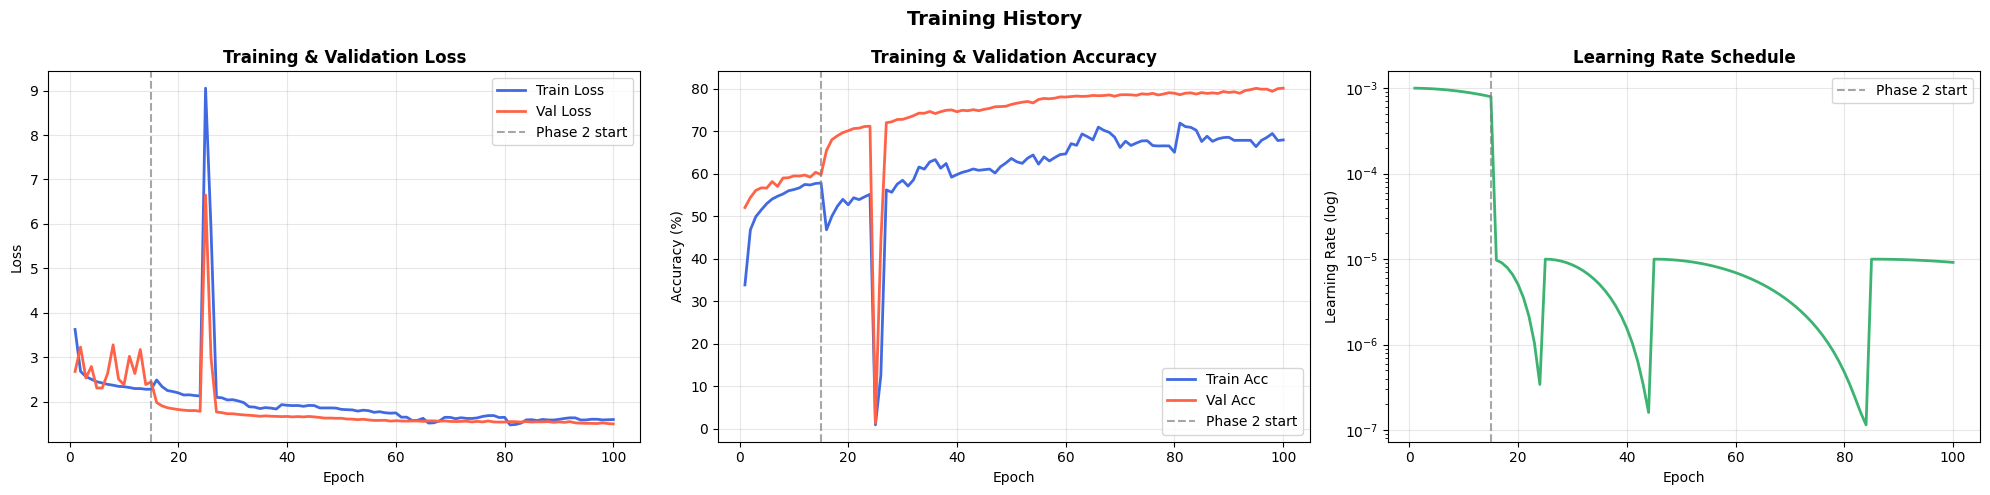


Best Val Accuracy: 80.12% at epoch 100


In [17]:
# ─── Load Best Model & Plot Curves ───

base_model = model.module if hasattr(model, 'module') else model
base_model.load_state_dict(torch.load(CONFIG['save_path'], map_location=DEVICE))
model.eval()
print(f"Best model loaded dari: {CONFIG['save_path']}")

epochs_range = range(1, len(history['train_loss']) + 1)
phase1_end   = PHASE1_EPOCHS

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax = axes[0]
ax.plot(epochs_range, history['train_loss'], label='Train Loss', color='royalblue', linewidth=2)
ax.plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=2)
ax.axvline(phase1_end, color='gray', linestyle='--', alpha=0.7, label='Phase 2 start')
ax.set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(epochs_range, [a*100 for a in history['train_acc']], label='Train Acc', color='royalblue', linewidth=2)
ax.plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val Acc',   color='tomato',    linewidth=2)
ax.axvline(phase1_end, color='gray', linestyle='--', alpha=0.7, label='Phase 2 start')
ax.set_title('Training & Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
ax.semilogy(epochs_range, history['lr'], color='mediumseagreen', linewidth=2)
ax.axvline(phase1_end, color='gray', linestyle='--', alpha=0.7, label='Phase 2 start')
ax.set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate (log)'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

best_val_acc_epoch = np.argmax(history['val_acc']) + 1
print(f"\nBest Val Accuracy: {max(history['val_acc'])*100:.2f}% at epoch {best_val_acc_epoch}")

## 18. Evaluasi Model pada Test Set

In [18]:
# ─── Evaluasi pada Test Set ───

@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in tqdm(loader, desc='Evaluating Test Set'):
        imgs = imgs.to(device)
        with torch.cuda.amp.autocast():
            outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

test_preds, test_labels, test_probs = get_predictions(model, test_loader, DEVICE)
test_accuracy = accuracy_score(test_labels, test_preds)

print(f"\nTEST SET RESULTS")
print(f"{'='*50}")
print(f"   Accuracy : {test_accuracy*100:.2f}%")
print(f"   Samples  : {len(test_labels):,}")

report = classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4)
print("\nCLASSIFICATION REPORT")
print("="*70)
print(report)

with open('/kaggle/working/classification_report.txt', 'w') as f:
    f.write(f"Test Accuracy: {test_accuracy*100:.4f}%\n\n")
    f.write(report)

Evaluating Test Set:   0%|          | 0/356 [00:00<?, ?it/s]


TEST SET RESULTS
   Accuracy : 80.15%
   Samples  : 11,363

CLASSIFICATION REPORT
                                 precision    recall  f1-score   support

                  adristyrannus     0.7647    0.8125    0.7879        32
       aleurocanthus spiniferus     0.9365    0.8551    0.8939        69
              alfalfa plant bug     0.3672    0.7015    0.4821        67
           alfalfa seed chalcid     0.4000    0.2105    0.2759        19
                 alfalfa weevil     0.7200    0.6792    0.6990        53
                    ampelophaga     0.7419    0.8961    0.8118        77
                            ant     0.9223    0.9845    0.9524       193
                         aphids     0.9383    0.7113    0.8092       620
               apolygus lucorum     0.4490    0.5641    0.5000        39
                       armyworm     0.7580    0.4703    0.5804       353
             asiatic rice borer     0.5889    0.5000    0.5408       106
           bactrocera tsuneonis     0.61

## 19. Analisis Confusion Matrix dan Per-Class Performance

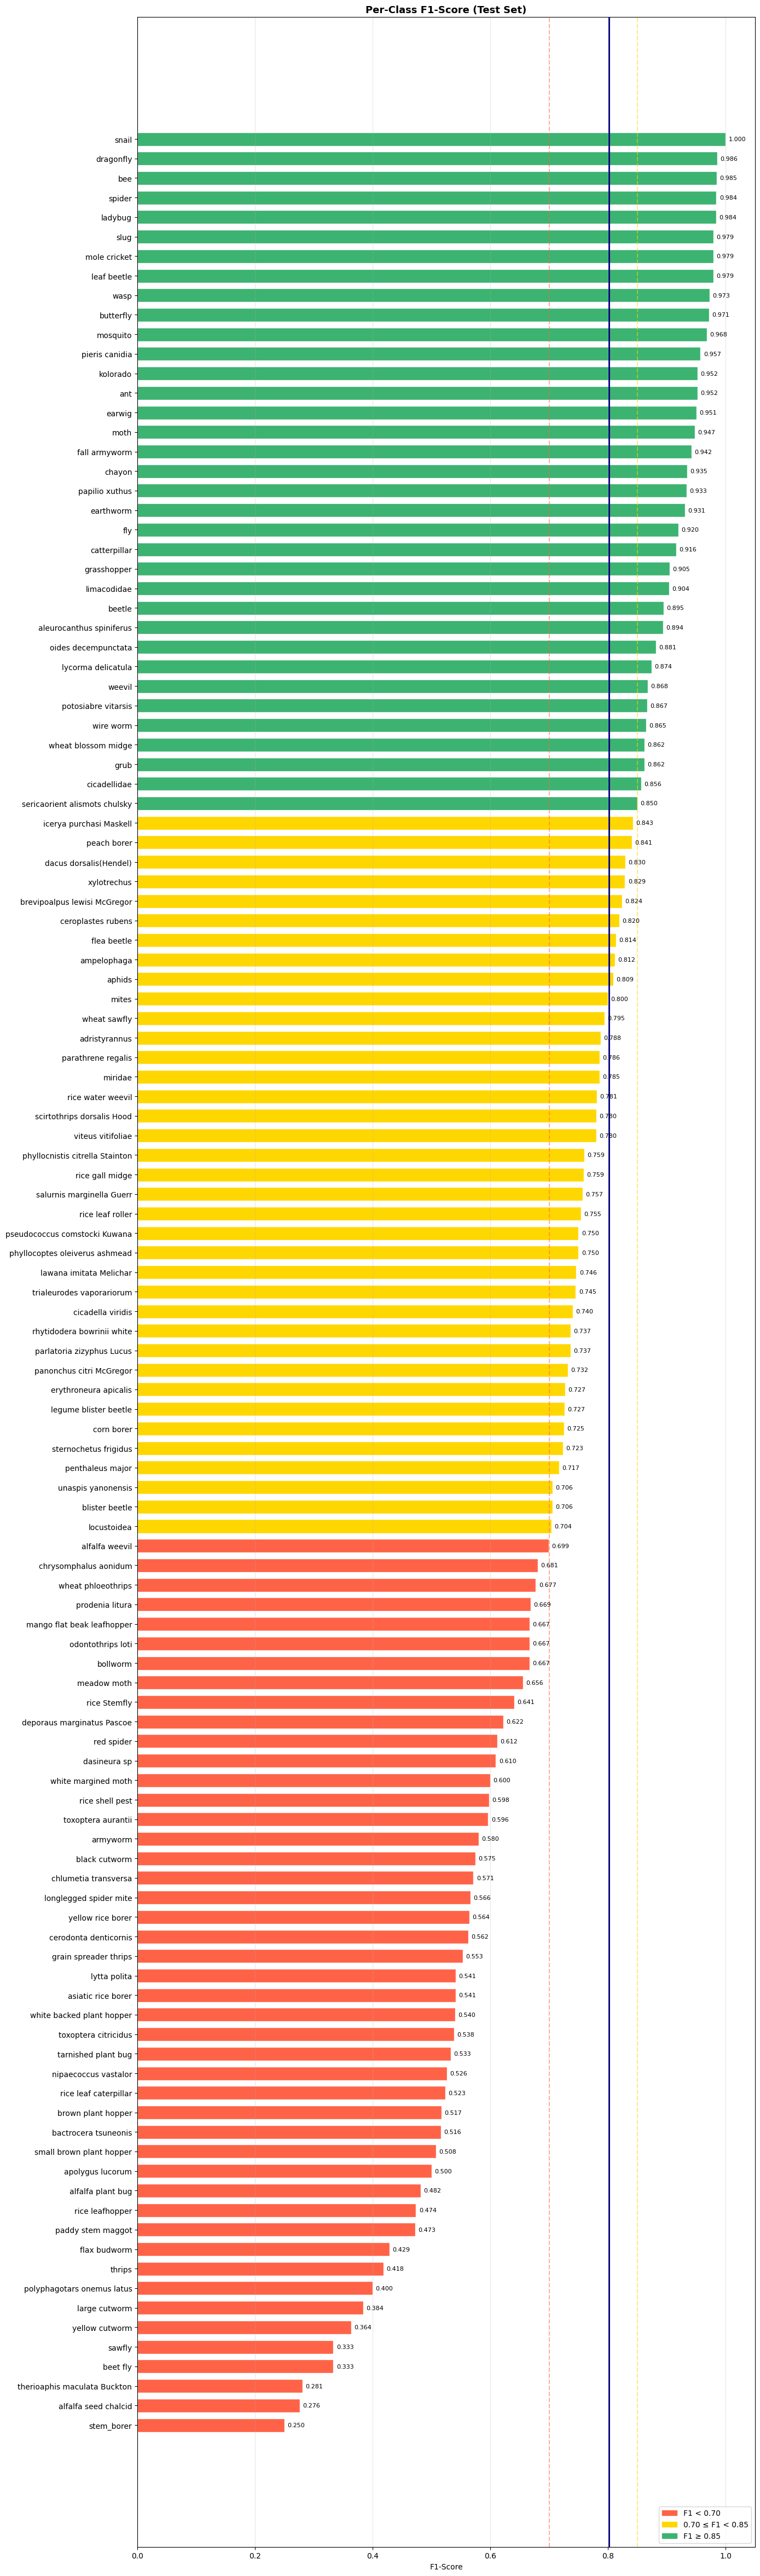

In [19]:
# ─── Confusion Matrix & Per-Class F1 ───

report_dict = classification_report(test_labels, test_preds, target_names=CLASS_NAMES, output_dict=True)
per_class_f1 = [report_dict[c]['f1-score'] for c in CLASS_NAMES]
sorted_idx   = np.argsort(per_class_f1)
sorted_cls   = [CLASS_NAMES[i] for i in sorted_idx]
sorted_f1    = [per_class_f1[i] for i in sorted_idx]
colors       = ['tomato' if f < 0.7 else 'gold' if f < 0.85 else 'mediumseagreen' for f in sorted_f1]

fig, ax = plt.subplots(figsize=(14, max(8, NUM_CLASSES * 0.4)))
bars = ax.barh(sorted_cls, sorted_f1, color=colors, edgecolor='white', height=0.7)
for bar, val in zip(bars, sorted_f1):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)
ax.axvline(0.7, color='tomato', linestyle='--', alpha=0.5)
ax.axvline(0.85, color='gold', linestyle='--', alpha=0.5)
ax.axvline(test_accuracy, color='navy', linestyle='-', linewidth=2, label=f'Overall Acc = {test_accuracy*100:.1f}%')
patches = [
    mpatches.Patch(color='tomato', label='F1 < 0.70'),
    mpatches.Patch(color='gold', label='0.70 ≤ F1 < 0.85'),
    mpatches.Patch(color='mediumseagreen', label='F1 ≥ 0.85'),
]
ax.legend(handles=patches, loc='lower right')
ax.set_title('Per-Class F1-Score (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('F1-Score'); ax.set_xlim(0, 1.05); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

cm = confusion_matrix(test_labels, test_preds)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig_size = max(12, NUM_CLASSES * 0.55)
fig, axes = plt.subplots(1, 2, figsize=(fig_size * 2, fig_size))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=axes[0], cmap='Blues', colorbar=False, xticks_rotation=45)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=7)
ConfusionMatrixDisplay(cm_normalized, display_labels=CLASS_NAMES).plot(ax=axes[1], cmap='Greens', colorbar=False, xticks_rotation=45, values_format='.2f')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=7)
plt.suptitle('Confusion Matrix - Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. Evaluasi Top-K Accuracy

In [20]:
# ─── Top-K Accuracy ───

def top_k_accuracy(probs, labels, k):
    top_k = np.argsort(probs, axis=1)[:, -k:]
    correct = sum(labels[i] in top_k[i] for i in range(len(labels)))
    return correct / len(labels)

top1 = top_k_accuracy(test_probs, test_labels, 1)
top3 = top_k_accuracy(test_probs, test_labels, 3)
top5 = top_k_accuracy(test_probs, test_labels, 5)

print("TOP-K ACCURACY (Test Set)")
print(f"   Top-1 : {top1*100:.2f}%")
print(f"   Top-3 : {top3*100:.2f}%")
print(f"   Top-5 : {top5*100:.2f}%")

TOP-K ACCURACY (Test Set)
   Top-1 : 80.14%
   Top-3 : 92.28%
   Top-5 : 94.73%


## 21. Export Model dan Penyimpanan Metadata

In [21]:
# ─── Model Export ───

metadata = {
    'model_name'      : CONFIG['model_name'],
    'num_classes'     : NUM_CLASSES,
    'class_names'     : CLASS_NAMES,
    'class_to_idx'    : train_dataset.class_to_idx,
    'img_size'        : IMG_SIZE,
    'input_channels'  : 3,
    'imagenet_mean'   : IMAGENET_MEAN,
    'imagenet_std'    : IMAGENET_STD,
    'test_accuracy'   : float(test_accuracy),
    'top3_accuracy'   : float(top3),
    'top5_accuracy'   : float(top5),
    'training_config' : CONFIG,
    'total_params'    : total,
    'trainable_params': trainable,
}

with open(CONFIG['metadata_path'], 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved: {CONFIG['metadata_path']}")

# TorchScript export
export_model = model.module if hasattr(model, 'module') else model
export_model.eval()
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

with torch.no_grad():
    traced_model = torch.jit.trace(export_model, dummy_input)

torchscript_path = '/kaggle/working/model_traced.pt'
traced_model.save(torchscript_path)
print(f"TorchScript model saved: {torchscript_path}")

# Verifikasi
loaded_ts = torch.jit.load(torchscript_path, map_location=DEVICE)
with torch.no_grad():
    out = loaded_ts(dummy_input)
print(f"   Output shape   : {out.shape}")
print(f"   TorchScript verified!")

# ONNX export (opsional)
try:
    onnx_path = '/kaggle/working/model.onnx'
    torch.onnx.export(export_model, dummy_input, onnx_path,
        export_params=True, opset_version=17, do_constant_folding=True,
        input_names=['input'], output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}})
    import onnx
    onnx.checker.check_model(onnx.load(onnx_path))
    print(f"ONNX model exported & verified!")
except ImportError:
    print("onnx tidak terinstall. Skip ONNX export.")
except Exception as e:
    print(f"ONNX export gagal: {e}")

output_files = glob.glob('/kaggle/working/*')
print("\nOutput files:")
for f in sorted(output_files):
    size_mb = os.path.getsize(f) / 1e6
    print(f"   {size_mb:>8.2f} MB  {f}")

Metadata saved: /kaggle/working/model_metadata.json
TorchScript model saved: /kaggle/working/model_traced.pt
   Output shape   : torch.Size([1, 118])
   TorchScript verified!
onnx tidak terinstall. Skip ONNX export.

Output files:
       6.92 MB  /kaggle/working/__notebook__.ipynb
      46.77 MB  /kaggle/working/best_model.pth
       0.00 MB  /kaggle/working/checkpoints
       0.61 MB  /kaggle/working/class_distribution.png
       0.01 MB  /kaggle/working/classification_report.txt
       4.04 MB  /kaggle/working/confusion_matrix.png
       0.07 MB  /kaggle/working/image_size_distribution.png
     139.46 MB  /kaggle/working/latest_checkpoint.pth
       0.01 MB  /kaggle/working/model_metadata.json
      47.62 MB  /kaggle/working/model_traced.pt
       0.71 MB  /kaggle/working/per_class_f1.png
       4.85 MB  /kaggle/working/sample_images.png
       0.17 MB  /kaggle/working/training_curves.png


## 22. Ringkasan Hasil Akhir dan Performa Model

In [22]:
# ─── Final Summary ───

print("="*65)
print("FINAL SUMMARY")
print("="*65)
print(f"  Model Architecture : {CONFIG['model_name']}")
print(f"  Total Parameters   : {total:,}")
print(f"  Image Size         : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Number of Classes  : {NUM_CLASSES}")
print()
print(f"  ─── PERFORMANCE ───")
print(f"  Test Accuracy (Top-1): {test_accuracy*100:.2f}%")
print(f"  Test Accuracy (Top-3): {top3*100:.2f}%")
print(f"  Test Accuracy (Top-5): {top5*100:.2f}%")
print(f"  Best Val Accuracy    : {early_stopping_p2.best_acc*100:.2f}%")
print()
print(f"  ─── OUTPUT FILES ───")
print(f"  {CONFIG['save_path']}     ← PyTorch state dict")
print(f"  {torchscript_path}  ← TorchScript (production)")
print(f"  {CONFIG['metadata_path']}← Model metadata")
print("="*65)

FINAL SUMMARY
  Model Architecture : efficientnet_b3
  Total Parameters   : 11,547,806
  Image Size         : 300x300
  Number of Classes  : 118

  ─── PERFORMANCE ───
  Test Accuracy (Top-1): 80.15%
  Test Accuracy (Top-3): 92.28%
  Test Accuracy (Top-5): 94.73%
  Best Val Accuracy    : 80.12%

  ─── OUTPUT FILES ───
  /kaggle/working/best_model.pth     ← PyTorch state dict
  /kaggle/working/model_traced.pt  ← TorchScript (production)
  /kaggle/working/model_metadata.json← Model metadata
